<a href="https://colab.research.google.com/github/Jephia-Robart/DBA-Data-Analysis/blob/main/DBA_R_in_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: ggplot2

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite

Cloning repository from GitHub: DBA-Data-Analysis...

... Loading file: [deliveries.csv] into R session...

✅ Done: deliveries.csv loaded.

... Loading file: [orders.csv] into R session...

✅ Done: orders.csv loaded.

... Loading file: [vehicles.csv] into R session...

✅ Done: vehicles.csv loaded.


--- DATABASE STATUS ---

Deliveries Dataset:  950  records

Orders Dataset:      1250  records

Vehicles Dataset:    120  records

-----------------------


Warning messag

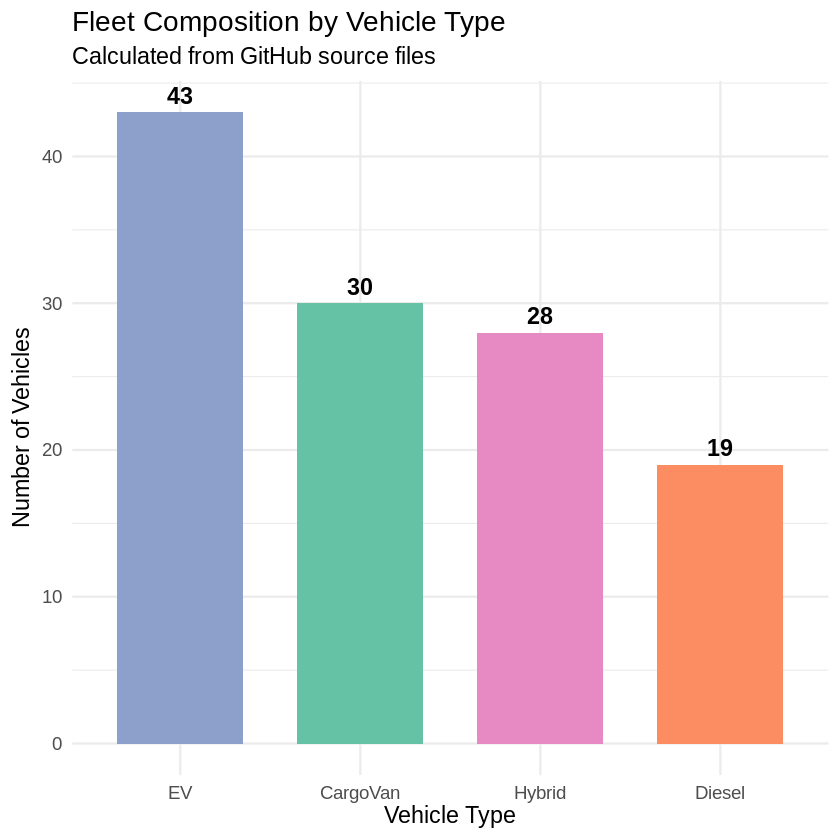

In [1]:
# 1. Install and load libraries
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")

library(sqldf)
library(ggplot2)

# 2. Clone the repository
message("Cloning repository from GitHub: DBA-Data-Analysis...")
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# 3. Load files
path_prefix <- "DBA-Data-Analysis/"
files_to_load <- c("deliveries.csv", "orders.csv", "vehicles.csv")

for (f in files_to_load) {
  message(paste0("... Loading file: [", f, "] into R session..."))
  assign(gsub(".csv", "", f), read.csv(paste0(path_prefix, f)))
  message(paste0("✅ Done: ", f, " loaded."))
}

message("\n--- DATABASE STATUS ---")
message(paste("Deliveries Dataset: ", nrow(deliveries), " records"))
message(paste("Orders Dataset:     ", nrow(orders), " records"))
message(paste("Vehicles Dataset:   ", nrow(vehicles), " records"))
message("-----------------------\n")

# Filter data using sqldf
active_deliveries <- sqldf("SELECT * FROM deliveries WHERE delivery_status = 'OnTime'")

# Create the Bar Chart
ggplot(vehicles, aes(x = reorder(vehicle_type, vehicle_type, function(x) -length(x)), fill = vehicle_type)) +
  geom_bar(width = 0.7) +
  geom_text(stat='count', aes(label=..count..), vjust=-0.5, fontface="bold") +
  scale_fill_brewer(palette = "Set2") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Fleet Composition by Vehicle Type",
    subtitle = "Calculated from GitHub source files",
    x = "Vehicle Type",
    y = "Number of Vehicles"
  ) +
  theme(legend.position = "none")

ggsave("fleet_composition_report.png", width = 10, height = 6, dpi = 300)
message("📊 Visualization saved: fleet_composition_report.png")

Cloning repository from GitHub...

... Loading [deliveries.csv] ...

... Loading [orders.csv] ...


--- CLEANING DATA ---

✅ Found 950 matching Order IDs between files.

✅ Found 343 deliveries marked as 'Delayed'


--- RUNNING ANALYTICS ---


--- GENERATING VISUALIZATION ---

✅ Chart generation done!



  service_type total_jobs delayed_count delay_percent
1      Medical        108            41         37.96
2       Parcel        230            87         37.83
3       Retail        224            84         37.50
4    Passenger        262            92         35.11
5     Business        126            39         30.95


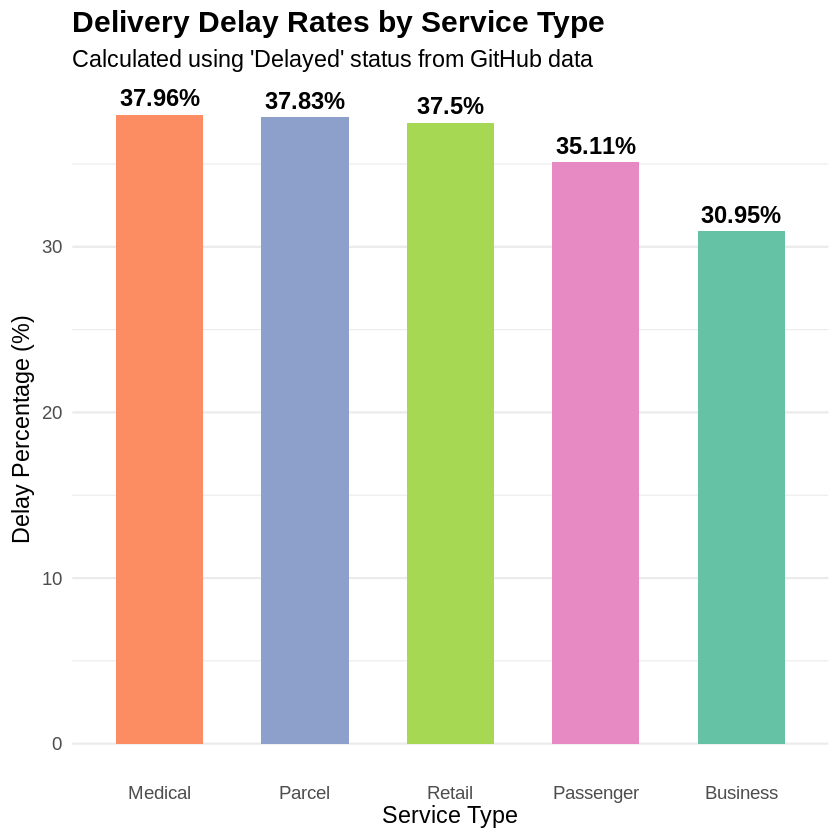

In [ ]:
# 1. Load Libraries
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")
library(sqldf)
library(ggplot2)

# 2. Clone Repository
message("Cloning repository from GitHub...")
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# 3. Load Files
path_prefix <- "DBA-Data-Analysis/"
message("... Loading [deliveries.csv] ...")
deliveries <- read.csv(paste0(path_prefix, "deliveries.csv"))
message("... Loading [orders.csv] ...")
orders <- read.csv(paste0(path_prefix, "orders.csv"))

# 4. Cleaning & ID Standardization
message("\n--- CLEANING DATA ---")
deliveries$order_id <- trimws(as.character(deliveries$order_id))
orders$order_id <- trimws(as.character(orders$order_id))

# Identify matches for diagnostic check
matches <- sum(deliveries$order_id %in% orders$order_id)
message(paste("✅ Found", matches, "matching Order IDs between files."))

# 5. Flag DELAYED Deliveries
deliveries$delivery_status <- trimws(as.character(deliveries$delivery_status))
deliveries$is_delayed <- ifelse(tolower(deliveries$delivery_status) == "delayed", 1, 0)

message(paste("✅ Found", sum(deliveries$is_delayed), "deliveries marked as 'Delayed'"))

#6. SQL Query
message("\n--- RUNNING ANALYTICS ---")
reliability_report <- sqldf("
  SELECT
    o.service_type,
    COUNT(d.delivery_id) AS total_jobs,
    SUM(d.is_delayed) AS delayed_count,
    ROUND((SUM(d.is_delayed) * 100.0 / COUNT(d.delivery_id)), 2) AS delay_percent
  FROM deliveries d
  INNER JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY delay_percent DESC
")

# 7. Chart
message("\n--- GENERATING VISUALIZATION ---")

if (nrow(reliability_report) > 0 && sum(reliability_report$delay_percent, na.rm=TRUE) > 0) {
  p <- ggplot(reliability_report, aes(x = reorder(service_type, -delay_percent), y = delay_percent, fill = service_type)) +
    geom_bar(stat = "identity", width = 0.6) +
    geom_text(aes(label = paste0(delay_percent, "%")), vjust = -0.5, fontface = "bold", size = 5) +
    scale_fill_brewer(palette = "Set2") +
    theme_minimal(base_size = 14) +
    labs(
      title = "Delivery Delay Rates by Service Type",
      subtitle = "Calculated using 'Delayed' status from GitHub data",
      x = "Service Type",
      y = "Delay Percentage (%)"
    ) +
    theme(
      legend.position = "none",
      plot.title = element_text(face = "bold", size = 18),
      panel.grid.major.x = element_blank()
    )

  print(p)
  ggsave("reliability_report.png", width = 10, height = 6)
  message("✅ Chart generation done!")
} else {
  message("❌ ERROR: The chart is still empty.")}

print(reliability_report)

Cloning repository from GitHub...

... Loading [orders.csv] into R session ...

✅ Done: orders.csv loaded.

... Cleaning and standardizing Pickup Zones ...


--- RUNNING SQL ANALYSIS ---


--- GENERATING CHART ---

Chart saved as 'zone_order_distribution.png'



  pickup_zone total_orders
1     Central          238
2        East          207
3       South          181
4       North          174
5        West          155
6   Riverside          151
7     Airport          144


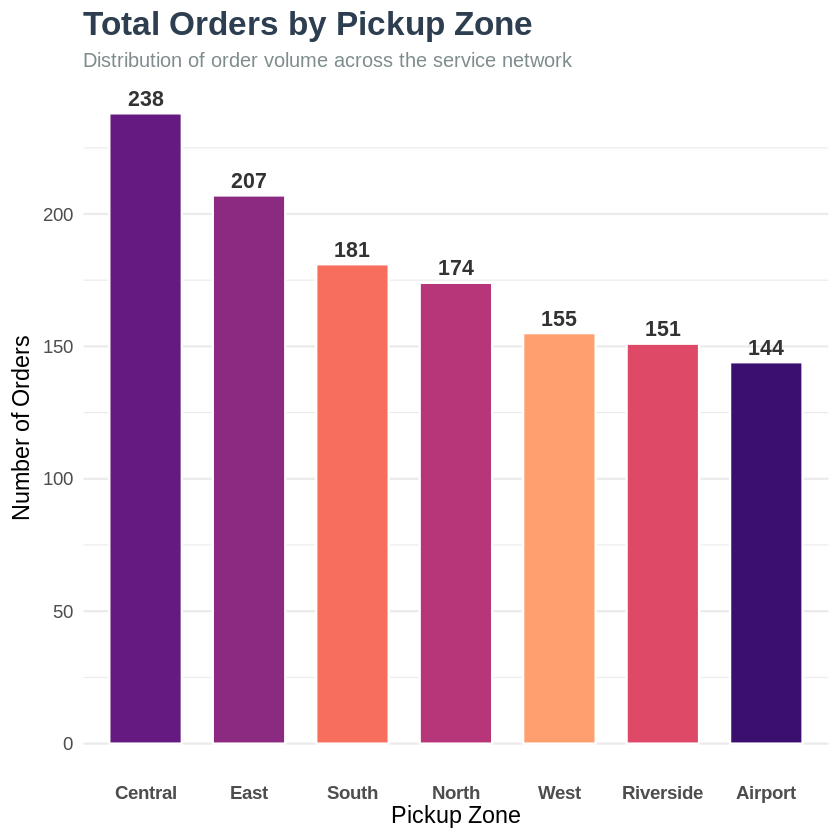

In [ ]:
#  Install and load libraries
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")
library(sqldf)
library(ggplot2)

# Clone Repository
message("Cloning repository from GitHub...")
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

path_prefix <- "DBA-Data-Analysis/"
message("... Loading [orders.csv] into R session ...")
orders <- read.csv(paste0(path_prefix, "orders.csv"))
message("✅ Done: orders.csv loaded.")

# Data Cleaning (CTR -> Central)
message("... Cleaning and standardizing Pickup Zones ...")
orders$pickup_zone <- trimws(as.character(orders$pickup_zone))
orders$pickup_zone[tolower(orders$pickup_zone) == "ctr"] <- "Central"
orders$pickup_zone <- tools::toTitleCase(tolower(orders$pickup_zone))

# SQL Query
message("\n--- RUNNING SQL ANALYSIS ---")
zone_data <- sqldf("
  SELECT pickup_zone, COUNT(order_id) as total_orders
  FROM orders
  GROUP BY pickup_zone
  ORDER BY total_orders DESC
")

message("\n--- GENERATING CHART ---")

p <- ggplot(zone_data, aes(x = reorder(pickup_zone, -total_orders), y = total_orders, fill = pickup_zone)) +
  geom_bar(stat = "identity", width = 0.7, color = "white") +
  geom_text(aes(label = total_orders), vjust = -0.5, fontface = "bold", size = 4.5, color = "#333333") +

  scale_fill_viridis_d(option = "magma", begin = 0.2, end = 0.8) +

  theme_minimal(base_size = 14) +
  labs(
    title = "Total Orders by Pickup Zone",
    subtitle = "Distribution of order volume across the service network",
    x = "Pickup Zone",
    y = "Number of Orders"
  ) +
  theme(
    legend.position = "none", # Hides legend as colors correspond to X-axis
    plot.title = element_text(face = "bold", size = 20, color = "#2c3e50"),
    plot.subtitle = element_text(size = 12, color = "#7f8c8d"),
    panel.grid.major.x = element_blank(), # Removes vertical grid lines for a cleaner look
    axis.text.x = element_text(face = "bold")
  )

print(p)
ggsave("zone_order_distribution.png", width = 10, height = 6, dpi = 300)
message("Chart saved as 'zone_order_distribution.png'")

print(zone_data)

Cloning repository from GitHub...

... Loading [vehicles.csv] into R session ...

✅ Done: vehicles.csv loaded.


--- RUNNING SQL ANALYSIS ---


--- GENERATING CHART ---

Chart saved as 'fleet_distribution_report.png'



  vehicle_type total_count
1           EV          43
2     CargoVan          30
3       Hybrid          28
4       Diesel          19


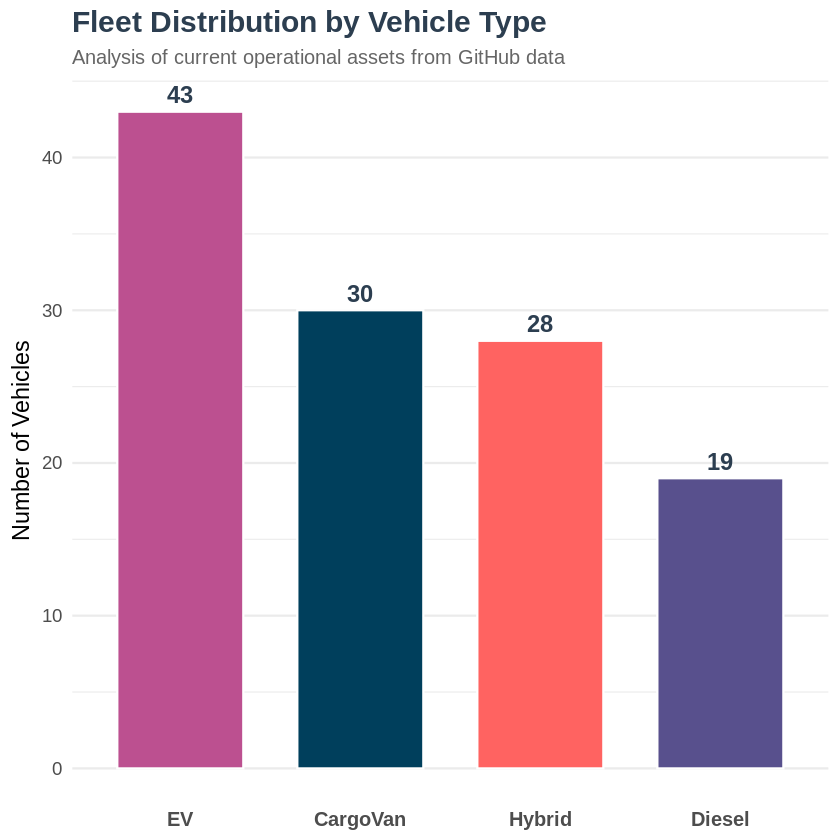

In [ ]:
# 1. Install and load libraries
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")
library(sqldf)
library(ggplot2)

# 2. Clone Repository
message("Cloning repository from GitHub...")
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# 3. Load File
path_prefix <- "DBA-Data-Analysis/"
message("... Loading [vehicles.csv] into R session ...")
vehicles <- read.csv(paste0(path_prefix, "vehicles.csv"))
message("✅ Done: vehicles.csv loaded.")

# 4. SQL Analysis
message("\n--- RUNNING SQL ANALYSIS ---")
vehicle_counts <- sqldf("
  SELECT vehicle_type, COUNT(vehicle_id) as total_count
  FROM vehicles
  GROUP BY vehicle_type
  ORDER BY total_count DESC
")

aesthetic_colors <- c("#003f5c", "#58508d", "#bc5090", "#ff6361", "#ffa600")

# 5. Chart
message("\n--- GENERATING CHART ---")

p <- ggplot(vehicle_counts, aes(x = reorder(vehicle_type, -total_count), y = total_count, fill = vehicle_type)) +
  geom_bar(stat = "identity", width = 0.7, color = "white") +

  # Add labels on top of bars
  geom_text(aes(label = total_count), vjust = -0.5, size = 5, fontface = "bold", color = "#2c3e50") +

  # Colors
  scale_fill_manual(values = aesthetic_colors) +

  # Applytheme
  theme_minimal(base_size = 14) +
  labs(
    title = "Fleet Distribution by Vehicle Type",
    subtitle = "Analysis of current operational assets from GitHub data",
    x = NULL,
    y = "Number of Vehicles"
  ) +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    plot.title = element_text(face = "bold", size = 18, color = "#2c3e50"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    axis.text.x = element_text(size = 12, face = "bold")
  )

print(p)
ggsave("fleet_distribution_report.png", width = 10, height = 6, dpi = 300)
message("Chart saved as 'fleet_distribution_report.png'")

print(vehicle_counts)

Cloning repository from GitHub...

... Loading [orders.csv] into R session ...

✅ Done: orders.csv loaded.


--- RUNNING SQL ANALYSIS ---


--- GENERATING VISUALIZATION ---

✅ Success! Market share chart saved as 'market_share_spectral.png'



  service_type total_orders
1    Passenger          341
2       Parcel          308
3       Retail          297
4     Business          165
5      Medical          139


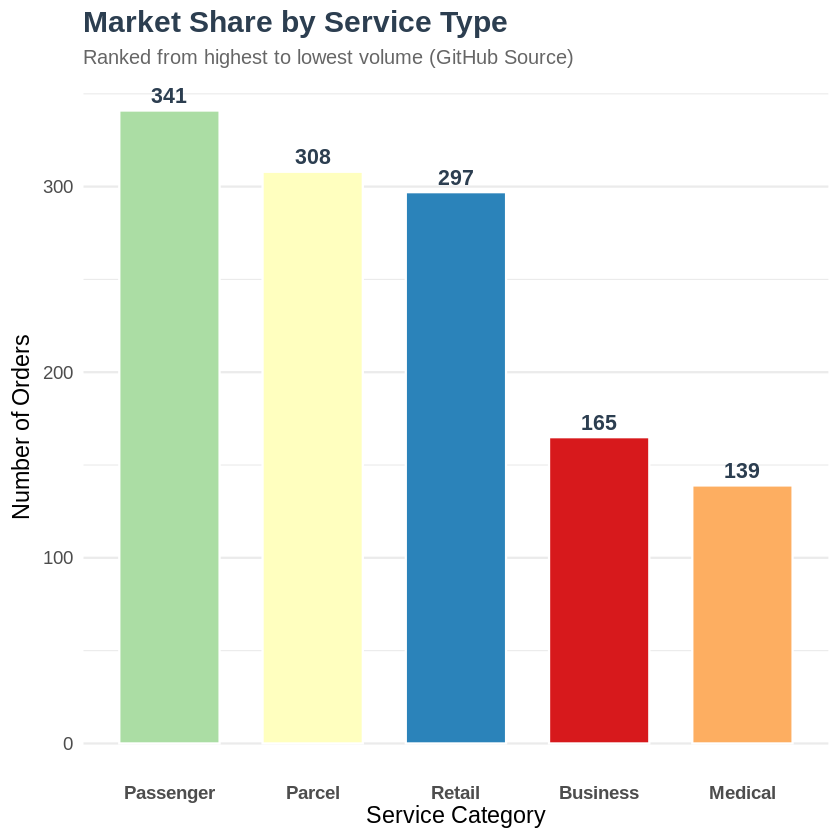

In [ ]:
# 1. Install and load libraries
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")
library(sqldf)
library(ggplot2)

# 2. Clone Repository
message("Cloning repository from GitHub...")
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# 3. Load File with Progress Feedback
path_prefix <- "DBA-Data-Analysis/"
message("... Loading [orders.csv] into R session ...")
orders <- read.csv(paste0(path_prefix, "orders.csv"))
message("✅ Done: orders.csv loaded.")

# 4. Agregate counts
message("\n--- RUNNING SQL ANALYSIS ---")
order_stats <- sqldf("
  SELECT service_type, COUNT(order_id) as total_orders
  FROM orders
  GROUP BY service_type
  ORDER BY total_orders DESC
")

# 5. Build the Chart=
message("\n--- GENERATING VISUALIZATION ---")

p <- ggplot(order_stats, aes(x = reorder(service_type, -total_orders), y = total_orders, fill = service_type)) +
  # Bar design
  geom_bar(stat = "identity", color = "white", width = 0.7) +

  # Add data labels on top of bars for clarity
  geom_text(aes(label = total_orders), vjust = -0.5, fontface = "bold", size = 4.5, color = "#2c3e50") +

  # Using the requested Spectral palette
  scale_fill_brewer(palette = "Spectral") +

  # Theme and Labels
  theme_minimal(base_size = 14) +
  labs(
    title = "Market Share by Service Type",
    subtitle = "Ranked from highest to lowest volume (GitHub Source)",
    x = "Service Category",
    y = "Number of Orders"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", size = 18, color = "#2c3e50"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(face = "bold")
  )

print(p)
ggsave("market_share_spectral.png", width = 10, height = 6, dpi = 300)
message("✅ Success! Market share chart saved as 'market_share_spectral.png'")

print(order_stats)

Cloning repository from GitHub...

... Loading [vehicles.csv] into R session ...

✅ Done: vehicles.csv loaded.

📊 Processing 67 active vehicles for analysis...

... Generating Battery Degradation Scatter Plot ...

... Generating Active Fleet Bar Chart ...

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


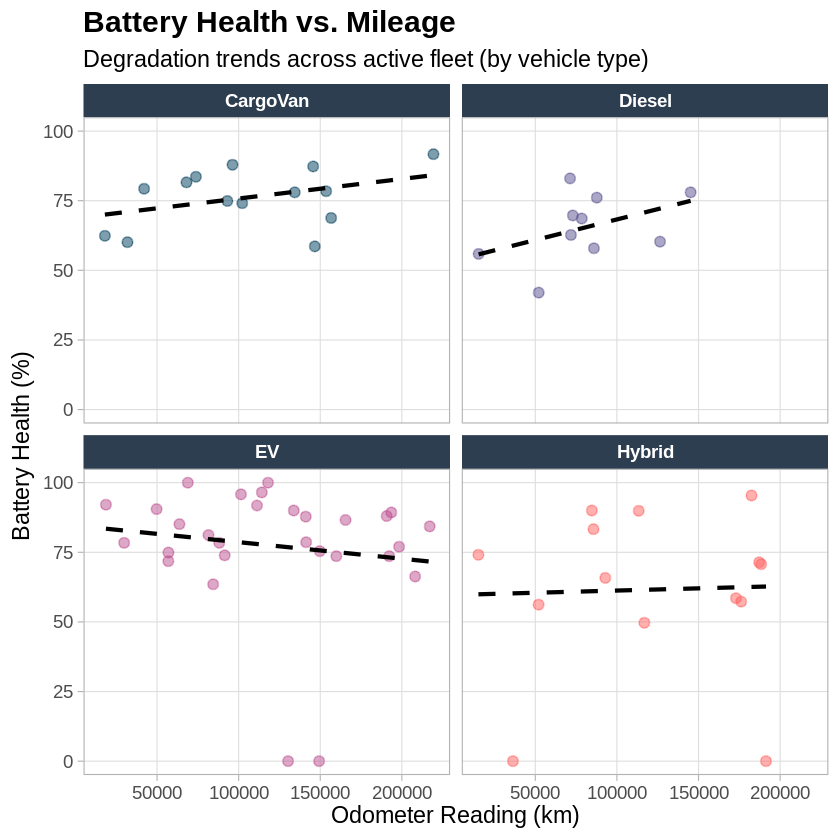


 Scatter plot and Bar chart generated!:

1. battery_health_scatter.png

2. active_fleet_bar.png



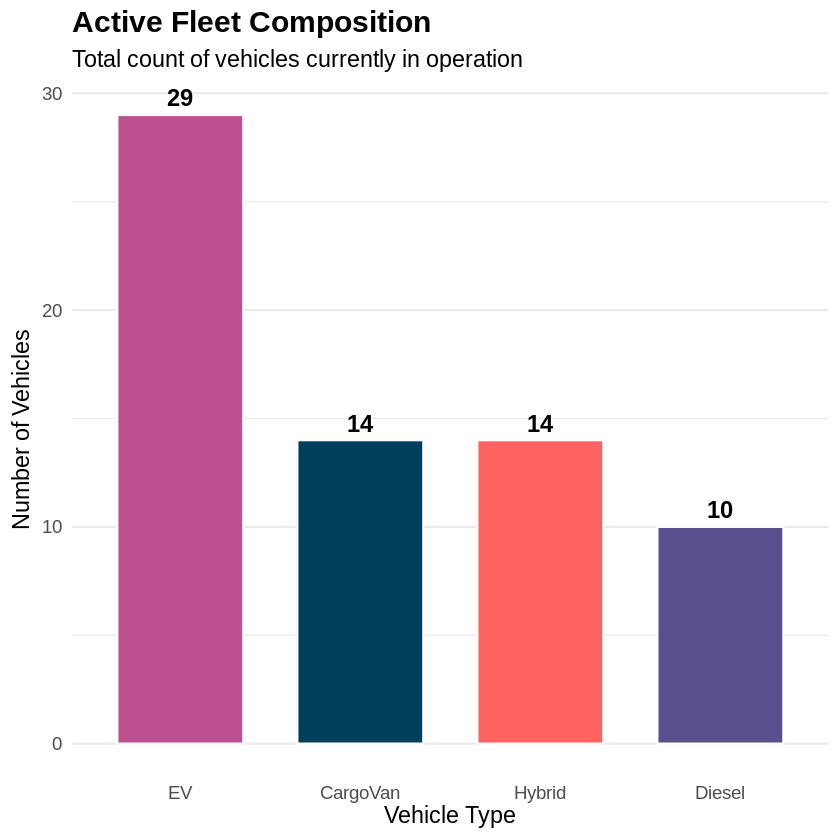

In [ ]:
# 1. Load the necessary libraries
if (!require("dplyr")) install.packages("dplyr")
if (!require("ggplot2")) install.packages("ggplot2")
library(dplyr)
library(ggplot2)

# 2. Clone Repository from GitHub
message("Cloning repository from GitHub...")
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# 3. Load Data
path_prefix <- "DBA-Data-Analysis/"
message("... Loading [vehicles.csv] into R session ...")
vehicles <- read.csv(paste0(path_prefix, "vehicles.csv"))
message("✅ Done: vehicles.csv loaded.")

aesthetic_colors <- c("#003f5c", "#58508d", "#bc5090", "#ff6361", "#ffa600")

active_vehicles <- vehicles %>%
  filter(maintenance_status == "Active")

message(paste("📊 Processing", nrow(active_vehicles), "active vehicles for analysis..."))

# --- CHART 1: SCATTER PLOT (Battery Health vs Mileage) ---
message("... Generating Battery Degradation Scatter Plot ...")

scatter_plot <- ggplot(active_vehicles, aes(x = odometer_km, y = battery_health_pct, color = vehicle_type)) +
  geom_point(size = 2.5, alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1.2, color = "black", linetype = "dashed") +
  scale_color_manual(values = aesthetic_colors) +
  facet_wrap(~vehicle_type) +
  theme_light(base_size = 14) +
  labs(
    title = "Battery Health vs. Mileage",
    subtitle = "Degradation trends across active fleet (by vehicle type)",
    x = "Odometer Reading (km)",
    y = "Battery Health (%)"
  ) +
  theme(
    legend.position = "none",
    strip.background = element_rect(fill = "#2c3e50"),
    strip.text = element_text(color = "white", face = "bold"),
    plot.title = element_text(face = "bold", size = 18),
    panel.grid.minor = element_blank()
  )

# --- CHART 2: BAR CHART (Active Fleet Distribution) ---
message("... Generating Active Fleet Bar Chart ...")

bar_chart <- active_vehicles %>%
  count(vehicle_type) %>%
  ggplot(aes(x = reorder(vehicle_type, -n), y = n, fill = vehicle_type)) +
  geom_bar(stat = "identity", width = 0.7, color = "white") +
  geom_text(aes(label = n), vjust = -0.5, fontface = "bold", size = 5) +
  scale_fill_manual(values = aesthetic_colors) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Active Fleet Composition",
    subtitle = "Total count of vehicles currently in operation",
    x = "Vehicle Type",
    y = "Number of Vehicles"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", size = 18),
    panel.grid.major.x = element_blank()
  )

print(scatter_plot)
ggsave("battery_health_scatter.png", scatter_plot, width = 10, height = 7)

print(bar_chart)
ggsave("active_fleet_bar.png", bar_chart, width = 10, height = 6)

message("\n Scatter plot and Bar chart generated!:")
message("1. battery_health_scatter.png")
message("2. active_fleet_bar.png")

In [ ]:
# ============================================
# SQL INSERT, UPDATE, DELETE in R (using sqldf)
# ============================================

install.packages("sqldf")
library(sqldf)

# Load data
message("Loading data from GitHub...")
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

deliveries <- read.csv("DBA-Data-Analysis/deliveries.csv")
orders <- read.csv("DBA-Data-Analysis/orders.csv")
drivers <- read.csv("DBA-Data-Analysis/drivers.csv")

# ============================================
# INSERT
# ============================================
cat("\n========== INSERT OPERATION ==========\n")

# Create a new delivery record using existing columns only
new_delivery <- data.frame(
  delivery_id = "DEL999",
  order_id = "O9999",
  driver_id = "D999",
  vehicle_id = "V999",
  hub_id = "H01",
  dispatch_time = "25/05/2026 09:00",
  delivery_completed_at = "25/05/2026 10:30",
  delivery_status = "OnTime",
  route_distance_km = 12.5,
  manual_route_override_count = 0,
  proof_of_completion_missing = 0,
  customer_rating_post_delivery = 4.8,
  fuel_or_charge_cost = 8.50,
  duration_minutes = 90
)

# Add to existing data
deliveries_updated <- rbind(deliveries, new_delivery)
cat("INSERTED new delivery record. New row count:", nrow(deliveries_updated), "\n")

# Verify using sqldf
sqldf("SELECT * FROM deliveries_updated WHERE delivery_id = 'DEL999'")

# ============================================
# UPDATE
# ============================================
cat("\n========== UPDATE OPERATION ==========\n")

# Before update
cat("Before update:\n")
sqldf("SELECT delivery_id, delivery_status, duration_minutes FROM deliveries WHERE delivery_id = 'DEL001'")

# update using sqldf syntax
deliveries_updated <- sqldf("
  UPDATE deliveries
  SET delivery_status = 'Delayed',
      duration_minutes = 145,
      customer_rating_post_delivery = 2.5
  WHERE delivery_id = 'DEL001'
")

# modification in R
deliveries[deliveries$delivery_id == "DEL001", "delivery_status"] <- "Delayed"
deliveries[deliveries$delivery_id == "DEL001", "duration_minutes"] <- 145
deliveries[deliveries$delivery_id == "DEL001", "customer_rating_post_delivery"] <- 2.5

cat("\nAfter update:\n")
sqldf("SELECT delivery_id, delivery_status, duration_minutes, customer_rating_post_delivery FROM deliveries WHERE delivery_id = 'DEL001'")

# ============================================
# DELETE
# ============================================
cat("\n========== DELETE OPERATION ==========\n")

# Count before deletion
count_before <- sqldf("SELECT COUNT(*) as count FROM deliveries WHERE delivery_id = 'DEL002'")
cat("Records with DEL002 before delete:", count_before$count, "\n")

# Delete the record
deliveries <- deliveries[deliveries$delivery_id != "DEL002", ]

# Count after deletion
count_after <- sqldf("SELECT COUNT(*) as count FROM deliveries WHERE delivery_id = 'DEL002'")
cat("Records with DEL002 after delete:", count_after$count, "\n")

cat("\nINSERT, UPDATE, DELETE operations demonstrated successfully!\n")

Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite

Loading data from GitHub...




========== INSERT OPERATION ==========
✅ INSERTED new delivery record. New row count: 951 


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,duration_minutes
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DEL999,O9999,D999,V999,H01,25/05/2026 09:00,25/05/2026 10:30,OnTime,12.5,0,0,4.8,8.5,90



========== UPDATE OPERATION ==========
Before update:


delivery_id,delivery_status,duration_minutes
<chr>,<chr>,<chr>


Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”



After update:


delivery_id,delivery_status,duration_minutes,customer_rating_post_delivery
<chr>,<chr>,<chr>,<dbl>



========== DELETE OPERATION ==========
Records with DEL002 before delete: 0 
Records with DEL002 after delete: 0 

✅ INSERT, UPDATE, DELETE operations demonstrated successfully!


In [ ]:
# ============================================
# SQL Aggregate Functions with sqldf
# Using ONLY columns that exist in your data
# ============================================

library(sqldf)

# Load daat
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

deliveries <- read.csv("DBA-Data-Analysis/deliveries.csv")
orders <- read.csv("DBA-Data-Analysis/orders.csv")
drivers <- read.csv("DBA-Data-Analysis/drivers.csv")
complaints <- read.csv("DBA-Data-Analysis/complaints.csv")
vehicles <- read.csv("DBA-Data-Analysis/vehicles.csv")

# ============================================
# AGGREGATE 1: Delivery performance by status
# ============================================
cat("\n========== AGGREGATE 1: Delivery Status Summary ==========\n")

delivery_summary <- sqldf("
  SELECT
    delivery_status,
    COUNT(delivery_id) AS total_deliveries,
    ROUND(AVG(route_distance_km), 2) AS avg_distance_km,
    ROUND(AVG(customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(fuel_or_charge_cost), 2) AS avg_fuel_cost,
    ROUND(AVG(duration_minutes), 2) AS avg_duration_minutes
  FROM deliveries
  WHERE delivery_status IS NOT NULL
  GROUP BY delivery_status
")

print(delivery_summary)

# ============================================
# AGGREGATE 2: Driver performance metrics
# ============================================
cat("\n========== AGGREGATE 2: Driver Performance ==========\n")

driver_performance <- sqldf("
  SELECT
    d.driver_id,
    dr.driver_rating,
    dr.years_experience,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) * 100, 2) AS on_time_percentage,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(d.duration_minutes), 2) AS avg_duration
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  ORDER BY on_time_percentage ASC
  LIMIT 10
")

print(driver_performance)

# ============================================
# AGGREGATE 3: Order value by service type
# ============================================
cat("\n========== AGGREGATE 3: Order Value Analysis ==========\n")

order_summary <- sqldf("
  SELECT
    service_type,
    COUNT(order_id) AS total_orders,
    ROUND(MIN(order_value), 2) AS min_order_value,
    ROUND(MAX(order_value), 2) AS max_order_value,
    ROUND(AVG(order_value), 2) AS avg_order_value,
    ROUND(SUM(order_value), 2) AS total_revenue
  FROM orders
  GROUP BY service_type
  ORDER BY total_revenue DESC
")

print(order_summary)

# ============================================
# AGGREGATE 4: Zone performance (pickup zones)
# ============================================
cat("\n========== AGGREGATE 4: Zone Performance ==========\n")

zone_performance <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(o.order_value), 2) AS avg_order_value,
    ROUND(SUM(o.order_value), 2) AS total_zone_revenue,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY total_zone_revenue DESC
")

print(zone_performance)

# ============================================
# AGGREGATE 5: Complaint analysis
# ============================================
cat("\n========== AGGREGATE 5: Complaint Metrics ==========\n")

complaint_summary <- sqldf("
  SELECT
    complaint_type,
    COUNT(complaint_id) AS total_complaints,
    ROUND(AVG(resolution_days), 2) AS avg_resolution_days,
    ROUND(SUM(compensation_amount), 2) AS total_compensation,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total_complaints DESC
")

print(complaint_summary)

# ============================================
# AGGREGATE 6: Vehicle maintenance impact
# ============================================
cat("\n========== AGGREGATE 6: Vehicle Maintenance Impact ==========\n")

vehicle_impact <- sqldf("
  SELECT
    v.maintenance_status,
    COUNT(DISTINCT v.vehicle_id) AS total_vehicles,
    ROUND(AVG(v.battery_health_pct), 2) AS avg_battery_health,
    ROUND(AVG(v.odometer_km), 2) AS avg_odometer_km
  FROM vehicles v
  GROUP BY v.maintenance_status
")

print(vehicle_impact)

cat("\n✅ All aggregate queries completed!\n")


========== AGGREGATE 1: Delivery Status Summary ==========
  delivery_status total_deliveries avg_distance_km avg_customer_rating
1         Delayed              343           14.39                3.59
2          Failed               19           12.30                3.65
3          OnTime              588           13.68                3.94
  avg_fuel_cost avg_duration_minutes
1         13.14              1001.66
2         11.58                 0.00
3         12.71               333.68

========== AGGREGATE 2: Driver Performance ==========
   driver_id driver_rating years_experience total_deliveries on_time_percentage
1       D029          3.84                2                1               0.00
2       D057          4.25                6                5               0.00
3       D063          4.03               12                3               0.00
4       D072          4.47               10                2               0.00
5       D015          4.34               11          

Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



  vehicle_type total_vehicles
1           EV             43
2     CargoVan             30
3       Hybrid             28
4       Diesel             19


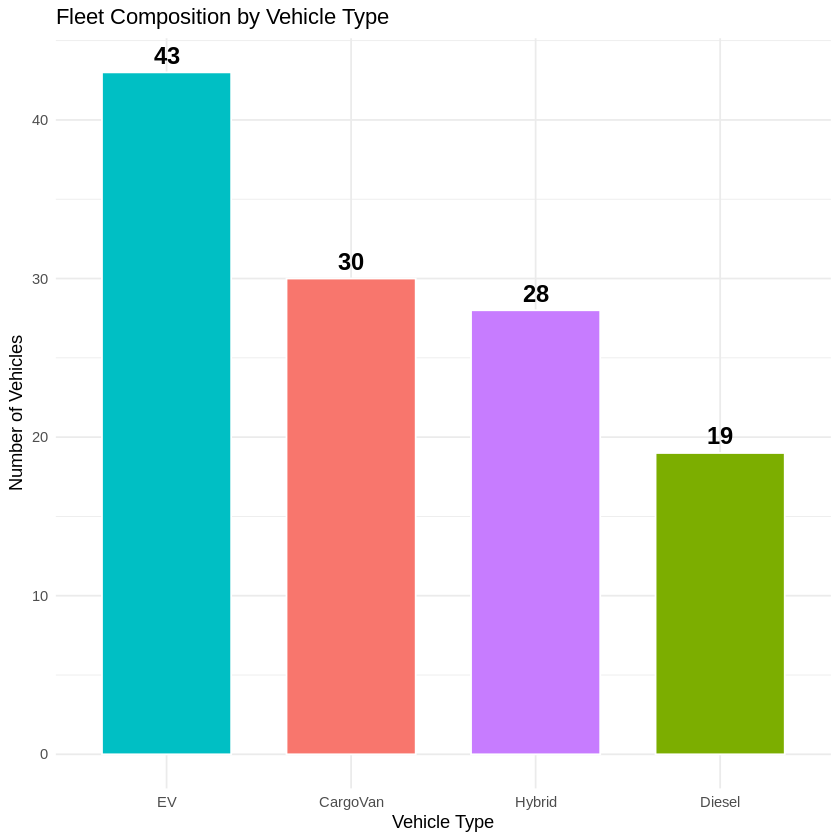

In [ ]:
# Fleet Composition by Vehicle Type
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")
library(sqldf)
library(ggplot2)

# Clone repository
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# Load data
vehicles <- read.csv("DBA-Data-Analysis/vehicles.csv")

# SQL Query
fleet_composition <- sqldf("
  SELECT
    vehicle_type,
    COUNT(vehicle_id) AS total_vehicles
  FROM vehicles
  GROUP BY vehicle_type
  ORDER BY total_vehicles DESC
")

print(fleet_composition)

# Bar chart
p1 <- ggplot(fleet_composition, aes(x = reorder(vehicle_type, -total_vehicles),
                                     y = total_vehicles,
                                     fill = vehicle_type)) +
  geom_bar(stat = "identity", width = 0.7, color = "white") +
  geom_text(aes(label = total_vehicles), vjust = -0.5, fontface = "bold", size = 5) +
  labs(title = "Fleet Composition by Vehicle Type",
       x = "Vehicle Type",
       y = "Number of Vehicles") +
  theme_minimal() +
  theme(legend.position = "none")
print(p1)

  service_type total_deliveries delayed_count delay_percentage
1      Medical              108            41            37.96
2       Parcel              230            87            37.83
3       Retail              224            84            37.50
4    Passenger              262            92            35.11
5     Business              126            39            30.95


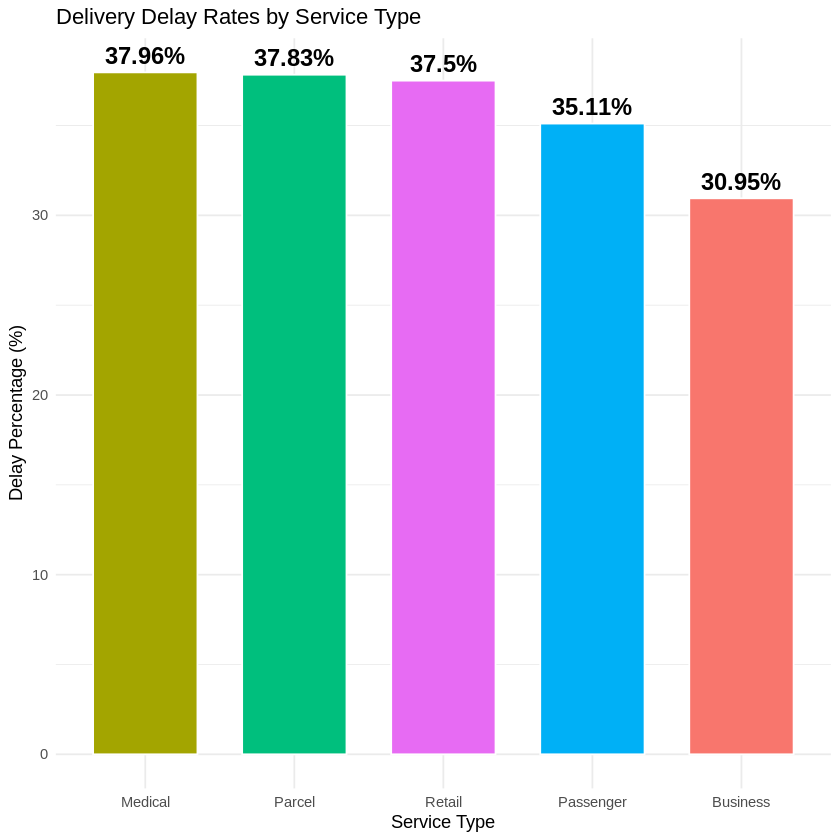

In [ ]:
# Delivery Delay Rates by Service Type

library(sqldf)
library(ggplot2)

# Clone repository
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# Load data
deliveries <- read.csv("DBA-Data-Analysis/deliveries.csv")
orders <- read.csv("DBA-Data-Analysis/orders.csv")

# Clean and prepare
deliveries$order_id <- trimws(as.character(deliveries$order_id))
orders$order_id <- trimws(as.character(orders$order_id))
deliveries$delivery_status <- trimws(as.character(deliveries$delivery_status))
deliveries$is_delayed <- ifelse(tolower(deliveries$delivery_status) == "delayed", 1, 0)

# SQL Query
delay_rates <- sqldf("
  SELECT
    o.service_type,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(d.is_delayed) AS delayed_count,
    ROUND((SUM(d.is_delayed) * 100.0 / COUNT(d.delivery_id)), 2) AS delay_percentage
  FROM deliveries d
  INNER JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY delay_percentage DESC
")

print(delay_rates)

# Bar chart
p2 <- ggplot(delay_rates, aes(x = reorder(service_type, -delay_percentage),
                               y = delay_percentage,
                               fill = service_type)) +
  geom_bar(stat = "identity", width = 0.7, color = "white") +
  geom_text(aes(label = paste0(delay_percentage, "%")), vjust = -0.5, fontface = "bold", size = 5) +
  labs(title = "Delivery Delay Rates by Service Type",
       x = "Service Type",
       y = "Delay Percentage (%)") +
  theme_minimal() +
  theme(legend.position = "none")
print(p2)

  pickup_zone total_orders
1     CENTRAL          238
2        EAST          207
3       SOUTH          181
4       NORTH          174
5        WEST          155
6   RIVERSIDE          151
7     AIRPORT          144


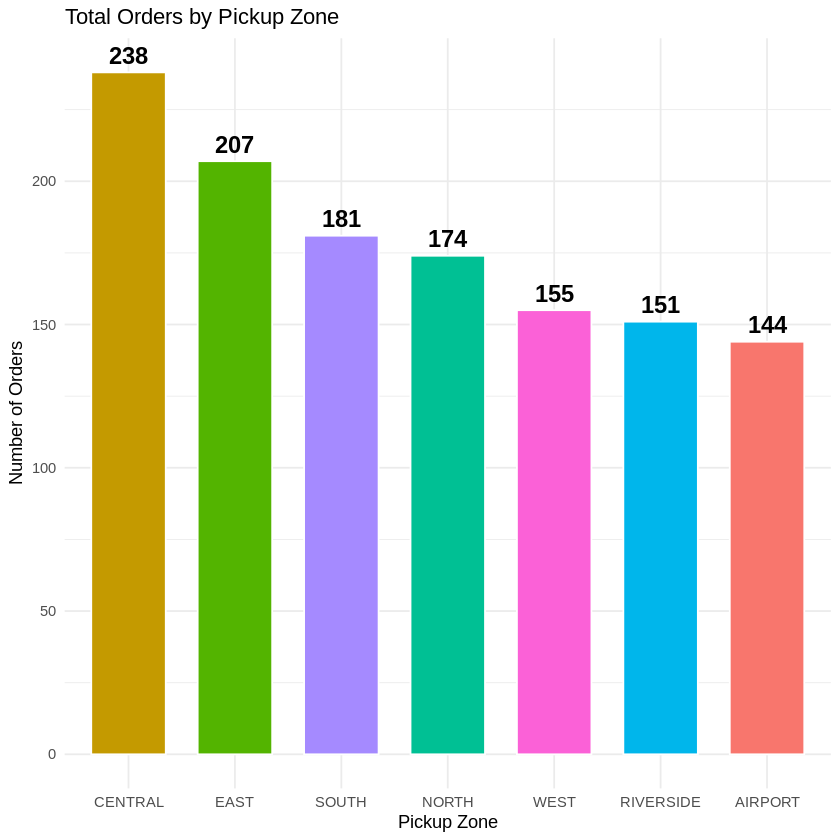

In [ ]:
library(sqldf)
library(ggplot2)

# Clone repository
system("rm -rf DBA-Data-Analysis && git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# Load data
orders <- read.csv("DBA-Data-Analysis/orders.csv")

# SQL Query
zone_orders <- sqldf("
  SELECT
    pickup_zone,
    COUNT(order_id) AS total_orders
  FROM orders
  GROUP BY pickup_zone
  ORDER BY total_orders DESC
")

print(zone_orders)

# Bar chart
p3 <- ggplot(zone_orders, aes(x = reorder(pickup_zone, -total_orders),
                               y = total_orders,
                               fill = pickup_zone)) +
  geom_bar(stat = "identity", width = 0.7, color = "white") +
  geom_text(aes(label = total_orders), vjust = -0.5, fontface = "bold", size = 5) +
  labs(title = "Total Orders by Pickup Zone",
       x = "Pickup Zone",
       y = "Number of Orders") +
  theme_minimal() +
  theme(legend.position = "none")
print(p3)


========== CUSTOMER LOYALTY STATISTICS ==========
Summary of loyalty_score:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  13.10   49.00   59.60   59.69   70.45   99.00      20 

Standard Deviation: 16.12467 


Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_density()`).”


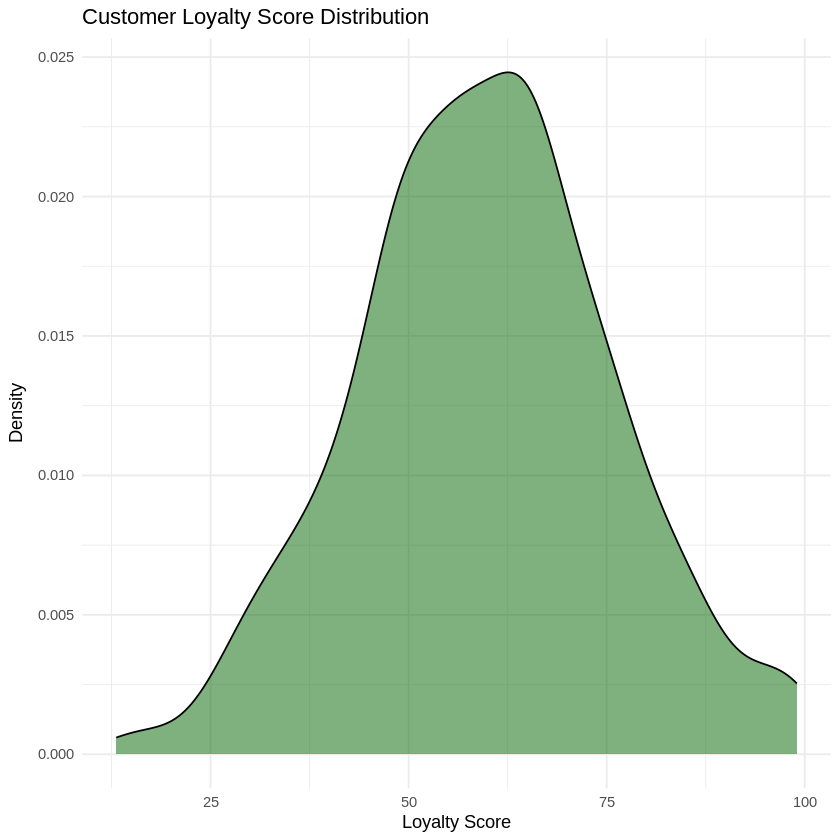

In [ ]:
# Customer Loyalty Score Distribution

library(ggplot2)

# Load data
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

customers <- read.csv("DBA-Data-Analysis/customers.csv")

# Summary statistics
cat("\n========== CUSTOMER LOYALTY STATISTICS ==========\n")
cat("Summary of loyalty_score:\n")
print(summary(customers$loyalty_score))
cat("\nStandard Deviation:", sd(customers$loyalty_score, na.rm = TRUE), "\n")

# Density plot
p2 <- ggplot(customers, aes(x = loyalty_score)) +
  geom_density(fill = "darkgreen", alpha = 0.5) +
  labs(title = "Customer Loyalty Score Distribution",
       x = "Loyalty Score", y = "Density") +
  theme_minimal()
print(p2)


========== COMPLAINT RESOLUTION STATISTICS ==========
Summary of resolution_days (resolved complaints only):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    3.00    7.00    7.73   11.00   25.00 

Standard Deviation: 5.171089 


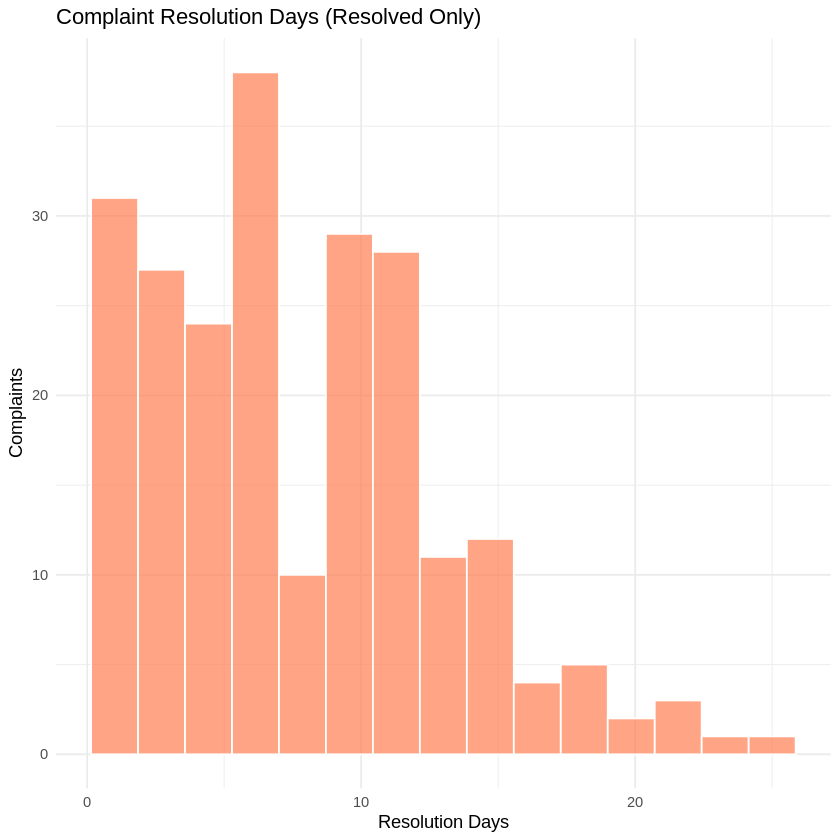

In [ ]:
# Complaint Resolution Days

library(ggplot2)

# Load data
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

complaints <- read.csv("DBA-Data-Analysis/complaints.csv")

# Filter out active complaints (resolution_days = 0 means not resolved yet)
resolved <- complaints[complaints$resolution_days > 0, ]

# Summary statistics
cat("\n========== COMPLAINT RESOLUTION STATISTICS ==========\n")
cat("Summary of resolution_days (resolved complaints only):\n")
print(summary(resolved$resolution_days))
cat("\nStandard Deviation:", sd(resolved$resolution_days, na.rm = TRUE), "\n")

# Histogram
p3 <- ggplot(resolved, aes(x = resolution_days)) +
  geom_histogram(bins = 15, fill = "coral", color = "white", alpha = 0.7) +
  labs(title = "Complaint Resolution Days (Resolved Only)",
       x = "Resolution Days", y = "Complaints") +
  theme_minimal()
print(p3)


========== CUSTOMER RATING STATISTICS ==========
Summary of customer_rating_post_delivery:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.320   4.030   3.808   4.550   5.000 

Standard Deviation: 1.002634 


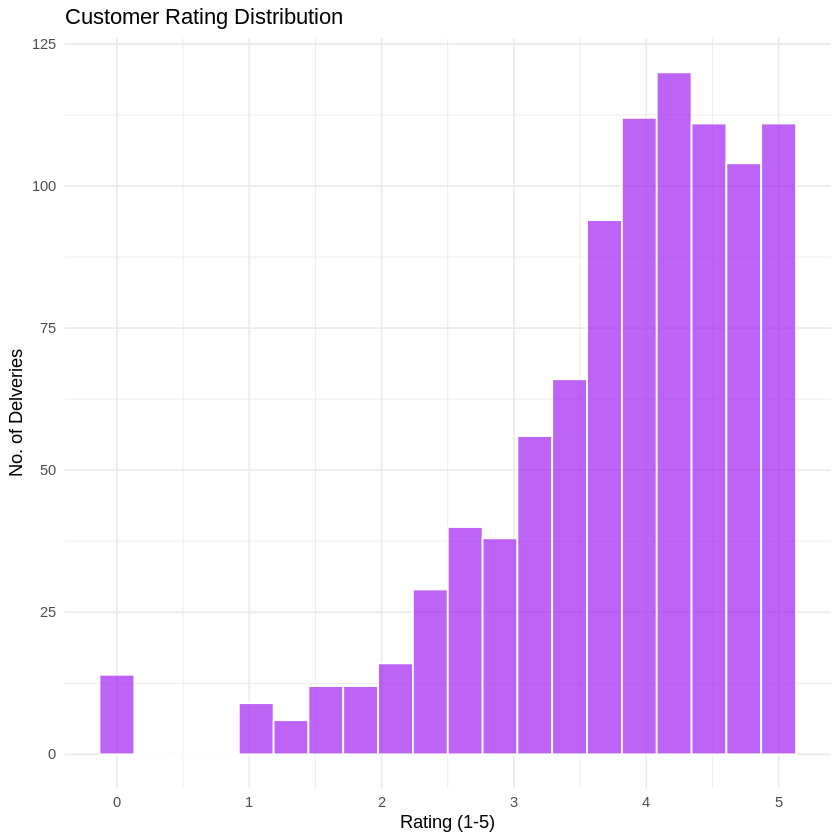

In [ ]:
# Customer Rating Post Delivery

library(ggplot2)

# Load data
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

deliveries <- read.csv("DBA-Data-Analysis/deliveries.csv")

# Summary statistics
cat("\n========== CUSTOMER RATING STATISTICS ==========\n")
cat("Summary of customer_rating_post_delivery:\n")
print(summary(deliveries$customer_rating_post_delivery))
cat("\nStandard Deviation:", sd(deliveries$customer_rating_post_delivery, na.rm = TRUE), "\n")

# Histogram
p4 <- ggplot(deliveries, aes(x = customer_rating_post_delivery)) +
  geom_histogram(bins = 20, fill = "purple", color = "white", alpha = 0.7) +
  labs(title = "Customer Rating Distribution",
       x = "Rating (1-5)", y = "No. of Delveries") +
  theme_minimal()
print(p4)

In [ ]:
# Vehicle Maintenance Impact

library(sqldf)
library(knitr)

# Clone repository
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# Load data
vehicles <- read.csv("DBA-Data-Analysis/vehicles.csv")

# SQL Query
maintenance_impact <- sqldf("
  SELECT
    maintenance_status,
    COUNT(vehicle_id) AS total_vehicles,
    ROUND(AVG(battery_health_pct), 2) AS avg_battery_health,
    ROUND(AVG(odometer_km), 2) AS avg_odometer_km
  FROM vehicles
  GROUP BY maintenance_status
")

# Print as formatted table
kable(maintenance_impact,
      col.names = c("Maintenance Status", "Total Vehicles", "Avg Battery Health (%)", "Avg Odometer (km)"))



|Maintenance Status | Total Vehicles| Avg Battery Health (%)| Avg Odometer (km)|
|:------------------|--------------:|----------------------:|-----------------:|
|Active             |             67|                  72.05|          111790.7|
|InRepair           |             36|                  76.64|          115704.6|
|Scheduled          |             17|                  77.67|          131376.1|

In [ ]:
# Customer Loyalty Segmentation

library(sqldf)
library(knitr)

# Clone repository
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# Load data
customers <- read.csv("DBA-Data-Analysis/customers.csv")

loyalty_segments <- sqldf("
  SELECT
    CASE
      WHEN loyalty_score >= 80 THEN 'High Loyalty (80-100)'
      WHEN loyalty_score >= 50 THEN 'Medium Loyalty (50-79)'
      ELSE 'Low Loyalty (0-49)'
    END AS loyalty_tier,
    COUNT(customer_id) AS customer_count,
    ROUND(AVG(app_engagement_score), 2) AS avg_engagement
  FROM customers
  GROUP BY loyalty_tier
  ORDER BY
    CASE loyalty_tier
      WHEN 'High Loyalty (80-100)' THEN 1
      WHEN 'Medium Loyalty (50-79)' THEN 2
      ELSE 3
    END
")

kable(loyalty_segments,
      col.names = c("Loyalty Tier", "Number of Customers", "Average App Engagement Score"))



|Loyalty Tier           | Number of Customers| Average App Engagement Score|
|:----------------------|-------------------:|----------------------------:|
|High Loyalty (80-100)  |                  65|                        57.61|
|Medium Loyalty (50-79) |                 392|                        58.92|
|Low Loyalty (0-49)     |                 193|                        56.70|

In [5]:
# Load the table formatting library
library(knitr)

new_delivery <- data.frame(
  delivery_id = "DEL999",
  order_id = "O9999",
  driver_id = "D999",
  vehicle_id = "V999",
  hub_id = "H01",
  dispatch_time = "25/05/2026 09:00",
  delivery_completed_at = "25/05/2026 10:30",
  delivery_status = "OnTime",
  route_distance_km = 12.5,
  manual_route_override_count = 0,
  proof_of_completion_missing = 0,
  customer_rating_post_delivery = 4.8,
  fuel_or_charge_cost = 8.50,
  duration_minutes = 90
)

kable(new_delivery)




|delivery_id |order_id |driver_id |vehicle_id |hub_id |dispatch_time    |delivery_completed_at |delivery_status | route_distance_km| manual_route_override_count| proof_of_completion_missing| customer_rating_post_delivery| fuel_or_charge_cost| duration_minutes|
|:-----------|:--------|:---------|:----------|:------|:----------------|:---------------------|:---------------|-----------------:|---------------------------:|---------------------------:|-----------------------------:|-------------------:|----------------:|
|DEL999      |O9999    |D999      |V999       |H01    |25/05/2026 09:00 |25/05/2026 10:30      |OnTime          |              12.5|                           0|                           0|                           4.8|                 8.5|               90|

In [12]:
library(knitr)
install.packages("sqldf")
library(sqldf)

# Clone repository
system("rm -rf DBA-Data-Analysis")
system("git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git")

# Load data
deliveries <- read.csv("DBA-Data-Analysis/deliveries.csv")

deliveries[deliveries$delivery_id == "DEL00001", "delivery_status"] <- "Delayed"
deliveries[deliveries$delivery_id == "DEL00001", "duration_minutes"] <- 145
deliveries[deliveries$delivery_id == "DEL00001", "customer_rating_post_delivery"] <- 2.5

kable(head(deliveries, 5))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)





|delivery_id |order_id |driver_id |vehicle_id |hub_id |dispatch_time    |delivery_completed_at |delivery_status | route_distance_km| manual_route_override_count| proof_of_completion_missing| customer_rating_post_delivery| fuel_or_charge_cost|duration_minutes |
|:-----------|:--------|:---------|:----------|:------|:----------------|:---------------------|:---------------|-----------------:|---------------------------:|---------------------------:|-----------------------------:|-------------------:|:----------------|
|DL00001     |O00938   |D004      |V056       |H05    |18/06/2024 10:57 |19/06/2024 09:05      |Delayed         |             17.26|                           1|                           0|                          3.07|               12.05|1328.0           |
|DL00002     |O00004   |D138      |V007       |H02    |11/01/2025 17:39 |11/01/2025 18:45      |OnTime          |             10.34|                           1|                           0|                         

In [15]:
# ============================================
# DELETE: Remove records using SQL WHERE clause
# ============================================

library(sqldf)

sqldf("DELETE FROM deliveries WHERE delivery_status = 'Failed'")

print("DELETE completed successfully - All Failed deliveries removed")

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

[1] "DELETE completed successfully - All Failed deliveries removed"
